## 04 - TabNet Model Training

### Import libraries and define paths

In [1]:
from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score,
)
from sklearn.model_selection import train_test_split

### Step 1a - Configure paths, reproducibility and device

In [2]:
PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_FILE = PROJECT / 'data' / 'processed_data.npz'
MODELS_DIR = PROJECT / 'models'
MODEL_PREFIX = MODELS_DIR / 'tabnet_model'
MODEL_FILE = MODELS_DIR / 'tabnet_model.zip'
RESULTS_DIR = PROJECT / 'results' / 'tabnet'
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Training device:', device_name)

Training device: cpu


### load the shared processed data and label encoder

In [3]:
if not PROCESSED_FILE.exists():
    raise FileNotFoundError('Run Notebook 01 before training the model.')
processed_data = np.load(PROCESSED_FILE, allow_pickle=True)
required = {'X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test'}
missing = required.difference(processed_data.files)
if missing:
    raise ValueError(f'Missing arrays in processed_data.npz: {sorted(missing)}')
X_train = processed_data['X_train'].astype(np.float32)
y_train = processed_data['y_train'].astype(np.int64)
X_val = processed_data['X_val'].astype(np.float32)
y_val = processed_data['y_val'].astype(np.int64)
X_test = processed_data['X_test'].astype(np.float32)
y_test = processed_data['y_test'].astype(np.int64)
print('X_train:', X_train.shape, 'X_val:', X_val.shape)
print('The test arrays are loaded but are reserved for the final evaluation cell.')

X_train: (1765652, 69) X_val: (252237, 69)
The test arrays are loaded but are reserved for the final evaluation cell.


### Load labels, feature names and class distributions

In [4]:
label_encoder = joblib.load(MODELS_DIR / 'label_encoder.joblib')
class_names = list(label_encoder.classes_)
number_of_classes = len(class_names)
BENIGN_INDEX = class_names.index('BENIGN')
all_labels = np.arange(number_of_classes)
feature_names = list(processed_data['feature_names']) if 'feature_names' in processed_data.files else [f'feature_{i}' for i in range(X_train.shape[1])]
print('Classes:', class_names)
distribution = pd.DataFrame({
    'train': np.bincount(y_train, minlength=number_of_classes),
    'validation': np.bincount(y_val, minlength=number_of_classes),
}, index=class_names)
display(distribution)

Classes: ['BENIGN', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']


,train,validation
BENIGN,1467538,209649
Botnet,1367,195
Brute Force,6407,915
DDoS,89611,12802
DoS,135623,19375
Heartbleed,8,1
Infiltration,25,4
PortScan,63573,9082
Web Attack,1500,214


### tune tabNet using validation' macro-F1

In [5]:
class ValidationMacroF1(Metric):
    _name = 'macro_f1'
    _maximize = True

    def __call__(self, y_true, y_score):
        return f1_score(y_true, np.argmax(y_score, axis=1), average='macro', zero_division=0)

BASE_CONFIG = {
    'n_d': 16, 'n_a': 16, 'n_steps': 5, 'gamma': 1.5,
    'lambda_sparse': 1e-4, 'learning_rate': 0.02,
    'batch_size': 4096, 'virtual_batch_size': 512,
    'max_epochs': 50, 'patience': 8, 'seed': RANDOM_STATE,
}
TUNING_GRID = [
    {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'learning_rate': 0.02},
    {'n_d': 24, 'n_a': 24, 'n_steps': 4, 'learning_rate': 0.02},
    {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'learning_rate': 0.01},
]

def build_tabnet(config):
    return TabNetClassifier(
        n_d=config['n_d'], n_a=config['n_a'], n_steps=config['n_steps'],
        gamma=config['gamma'], lambda_sparse=config['lambda_sparse'],
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': config['learning_rate']},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={'step_size': 20, 'gamma': 0.9},
        mask_type='entmax', seed=config['seed'], verbose=0,
        device_name=device_name,
    )

def tabnet_history(model):
    history = model.history
    return history.history if hasattr(history, 'history') else history

def macro_f1_history(model):
    history = tabnet_history(model)
    matching_keys = [key for key in history if 'macro_f1' in key]
    if not matching_keys:
        raise KeyError(f'Could not find macro-F1 in TabNet history: {list(history)}')
    return history[matching_keys[0]]

### run the validation only hyperparameter search

In [6]:
tuning_results = []
for trial_number, settings in enumerate(TUNING_GRID, start=1):
    trial_config = {**BASE_CONFIG, **settings, 'seed': RANDOM_STATE + trial_number}
    print(f'\nTrial {trial_number}/{len(TUNING_GRID)}: {settings}')
    set_seed(trial_config['seed'])
    trial_model = build_tabnet(trial_config)
    trial_start = time.perf_counter()
    trial_model.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], eval_name=['validation'],
        eval_metric=[ValidationMacroF1], max_epochs=trial_config['max_epochs'],
        patience=trial_config['patience'], batch_size=trial_config['batch_size'],
        virtual_batch_size=trial_config['virtual_batch_size'], weights=1,
        drop_last=False, compute_importance=False,
    )
    trial_macro_f1 = f1_score(y_val, trial_model.predict(X_val), average='macro', zero_division=0)
    trial_history = macro_f1_history(trial_model)
    tuning_results.append({
        **settings, 'trial': trial_number,
        'best_validation_macro_f1': float(max(trial_history)),
        'final_validation_macro_f1': float(trial_macro_f1),
        'epochs_run': len(trial_history),
        'training_seconds': time.perf_counter() - trial_start,
    })

tuning_table = pd.DataFrame(tuning_results).sort_values('best_validation_macro_f1', ascending=False)
tuning_table.to_csv(RESULTS_DIR / 'tuning_results.csv', index=False)
display(tuning_table)
best_settings = tuning_table.iloc[0].to_dict()
FINAL_CONFIG = {
    **BASE_CONFIG,
    'n_d': int(best_settings['n_d']),
    'n_a': int(best_settings['n_a']),
    'n_steps': int(best_settings['n_steps']),
    'learning_rate': float(best_settings['learning_rate']),
}
print('Selected by validation macro-F1:', FINAL_CONFIG)


Trial 1/3: {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'learning_rate': 0.02}

Early stopping occurred at epoch 11 with best_epoch = 3 and best_validation_macro_f1 = 0.67422


d:\Projects\SE4050-DL\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Trial 2/3: {'n_d': 24, 'n_a': 24, 'n_steps': 4, 'learning_rate': 0.02}

Early stopping occurred at epoch 21 with best_epoch = 13 and best_validation_macro_f1 = 0.67408


d:\Projects\SE4050-DL\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Trial 3/3: {'n_d': 32, 'n_a': 32, 'n_steps': 5, 'learning_rate': 0.01}

Early stopping occurred at epoch 13 with best_epoch = 5 and best_validation_macro_f1 = 0.65283


d:\Projects\SE4050-DL\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,n_d,n_a,n_steps,learning_rate,trial,best_validation_macro_f1,final_validation_macro_f1,epochs_run,training_seconds
0,16,16,3,0.02,1,0.674215,0.674215,12,647.516844
1,24,24,4,0.02,2,0.674082,0.674082,22,1543.999544
2,32,32,5,0.01,3,0.652833,0.652833,14,1527.400128


Selected by validation macro-F1: {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.5, 'lambda_sparse': 0.0001, 'learning_rate': 0.02, 'batch_size': 4096, 'virtual_batch_size': 512, 'max_epochs': 50, 'patience': 8, 'seed': 42}


### Train the final model and save validation history

In [8]:
set_seed(RANDOM_STATE)
tabnet_model = build_tabnet(FINAL_CONFIG)
training_start = time.perf_counter()
tabnet_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_name=['validation'],
    eval_metric=[ValidationMacroF1], max_epochs=FINAL_CONFIG['max_epochs'],
    patience=FINAL_CONFIG['patience'], batch_size=FINAL_CONFIG['batch_size'],
    virtual_batch_size=FINAL_CONFIG['virtual_batch_size'], weights=1,
    drop_last=False, compute_importance=False,
)
training_seconds = time.perf_counter() - training_start
final_macro_f1_history = macro_f1_history(tabnet_model)
best_validation_macro_f1 = float(max(final_macro_f1_history))
tabnet_model.save_model(str(MODEL_PREFIX))
history = pd.DataFrame(tabnet_history(tabnet_model))
history.to_csv(RESULTS_DIR / 'training_history.csv', index=False)
with open(RESULTS_DIR / 'config.json', 'w') as file:
    json.dump(FINAL_CONFIG, file, indent=2)
print(f'Best validation macro-F1: {best_validation_macro_f1:.4f}')
print(f'Model saved: {MODEL_FILE}')


Early stopping occurred at epoch 25 with best_epoch = 17 and best_validation_macro_f1 = 0.71499
Successfully saved model at d:\Projects\SE4050-DL\models\tabnet_model.zip
Best validation macro-F1: 0.7150
Model saved: d:\Projects\SE4050-DL\models\tabnet_model.zip


d:\Projects\SE4050-DL\.venv\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


### Plot training loss and validation macro-F1

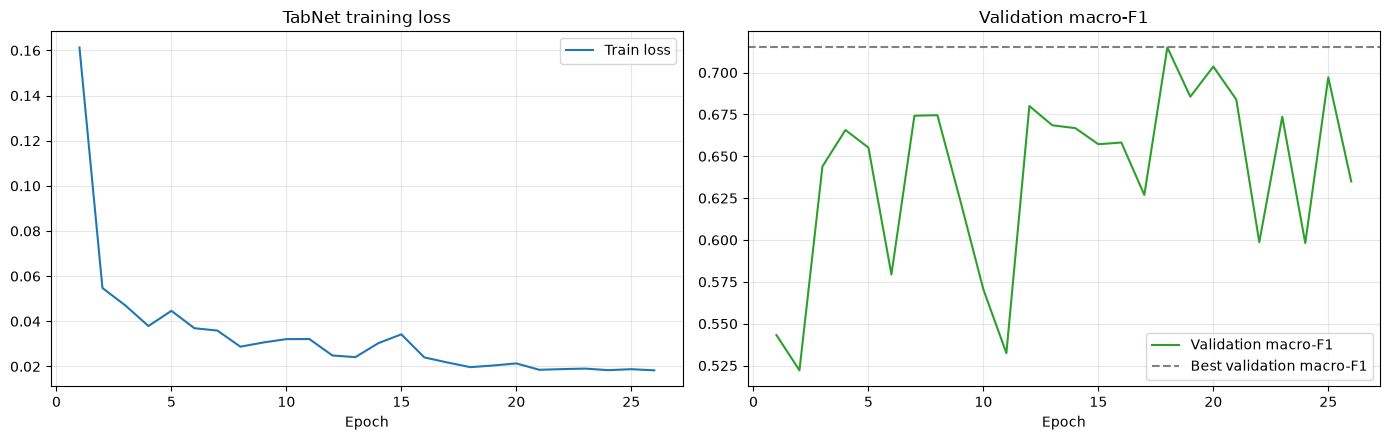

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history.index + 1, history['loss'], label='Train loss')
axes[0].set_title('TabNet training loss')
axes[1].plot(history.index + 1, final_macro_f1_history, color='tab:green', label='Validation macro-F1')
axes[1].axhline(best_validation_macro_f1, color='grey', linestyle='--', label='Best validation macro-F1')
axes[1].set_title('Validation macro-F1')
for axis in axes:
    axis.set_xlabel('Epoch')
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curves.png', dpi=150)
plt.show()

### Measure train/validation generalisation and validation-only explainability

In [10]:
train_predictions = tabnet_model.predict(X_train)
val_predictions = tabnet_model.predict(X_val)
generalisation = pd.DataFrame([
    {
        'split': split_name,
        'accuracy': accuracy_score(targets, predictions),
        'balanced_accuracy': balanced_accuracy_score(targets, predictions),
        'macro_f1': f1_score(targets, predictions, average='macro', zero_division=0),
        'weighted_f1': f1_score(targets, predictions, average='weighted', zero_division=0),
    }
    for split_name, targets, predictions in [('train', y_train, train_predictions), ('validation', y_val, val_predictions)]
]).set_index('split')
generalisation.to_csv(RESULTS_DIR / 'generalisation.csv')
display(generalisation.round(4))

,accuracy,balanced_accuracy,macro_f1,weighted_f1
split,,,,
train,0.9717,0.9918,0.7067,0.975
validation,0.9717,0.9363,0.7150,0.975


### Generate validation only TabNet explainability outputs

In [11]:
explain_size = min(5000, len(y_val))
rng = np.random.default_rng(RANDOM_STATE)
all_validation_indices = np.arange(len(y_val))
class_labels, class_counts = np.unique(y_val, return_counts=True)
rare_first_labels = class_labels[np.argsort(class_counts)]

if explain_size == len(y_val):
    explain_indices = all_validation_indices
else:
    representative_count = min(explain_size, len(rare_first_labels))
    representatives = [
        rng.choice(np.flatnonzero(y_val == label))
        for label in rare_first_labels[:representative_count]
    ]
    remaining_indices = np.setdiff1d(all_validation_indices, representatives, assume_unique=False)
    extra_count = explain_size - len(representatives)
    extras = rng.choice(remaining_indices, size=extra_count, replace=False) if extra_count else np.array([], dtype=int)
    explain_indices = np.concatenate([np.asarray(representatives, dtype=int), extras])
    rng.shuffle(explain_indices)

explain_start = time.perf_counter()
M_explain, masks = tabnet_model.explain(X_val[explain_indices])
explain_seconds = time.perf_counter() - explain_start
importance_values = np.asarray(M_explain, dtype=np.float64).sum(axis=0)
importance_values /= max(importance_values.sum(), 1e-12)
global_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values,
}).sort_values('importance', ascending=False)
global_importance.to_csv(RESULTS_DIR / 'feature_importance.csv', index=False)
mask_arrays = {
    f'mask_step_{step}': np.asarray(mask, dtype=np.float32)
    for step, mask in masks.items()
}
np.savez_compressed(
    RESULTS_DIR / 'explainability_masks.npz',
    indices=explain_indices,
    M_explain=np.asarray(M_explain, dtype=np.float32),
    **mask_arrays,
)
display(global_importance.head(20))

,feature,importance
57,Init_Win_bytes_forward,0.229577
48,ECE Flag Count,0.139874
0,Destination Port,0.125526
46,URG Flag Count,0.099921
43,RST Flag Count,0.055156
11,Bwd Packet Length Min,0.045873
44,PSH Flag Count,0.036201
28,Bwd IAT Max,0.020993
9,Fwd Packet Length Std,0.020917
1,Flow Duration,0.020326


### Plot global feature importance

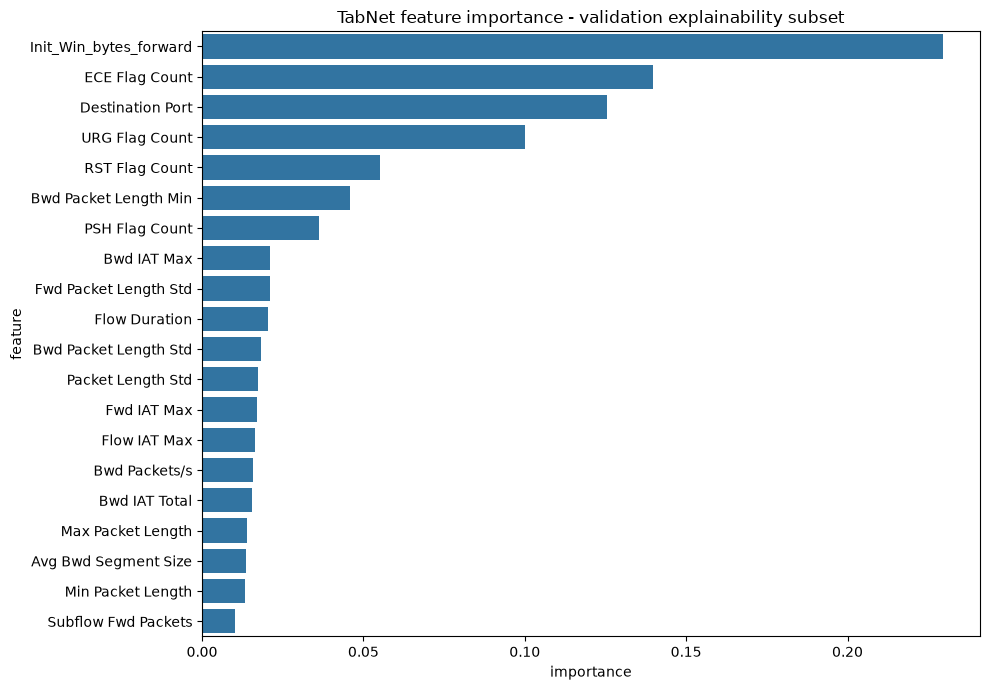

In [12]:
plt.figure(figsize=(10, 7))
sns.barplot(data=global_importance.head(20), x='importance', y='feature', color='tab:blue')
plt.title('TabNet feature importance - validation explainability subset')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150)
plt.show()

### Perform the single final test evaluation

In [13]:
if device_name == 'cuda':
    torch.cuda.synchronize()
inference_start = time.perf_counter()
test_probabilities = tabnet_model.predict_proba(X_test)
if device_name == 'cuda':
    torch.cuda.synchronize()
inference_seconds = time.perf_counter() - inference_start
test_predictions = test_probabilities.argmax(axis=1)
print(f'Test inference: {inference_seconds:.2f}s for {len(X_test):,} rows')

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, test_predictions, labels=all_labels, zero_division=0,
)
per_class_metrics = pd.DataFrame({
    'class': class_names,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
})
per_class_metrics.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)
multiclass_metrics = {
    'accuracy': accuracy_score(y_test, test_predictions),
    'macro_precision': precision_recall_fscore_support(y_test, test_predictions, average='macro', zero_division=0)[0],
    'macro_recall': precision_recall_fscore_support(y_test, test_predictions, average='macro', zero_division=0)[1],
    'macro_f1': f1_score(y_test, test_predictions, average='macro', zero_division=0),
    'weighted_precision': precision_recall_fscore_support(y_test, test_predictions, average='weighted', zero_division=0)[0],
    'weighted_recall': precision_recall_fscore_support(y_test, test_predictions, average='weighted', zero_division=0)[1],
    'weighted_f1': f1_score(y_test, test_predictions, average='weighted', zero_division=0),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_predictions),
}
display(pd.Series(multiclass_metrics).round(4))

Test inference: 7.49s for 504,473 rows


accuracy              0.9718
macro_precision       0.6641
macro_recall          0.9446
macro_f1              0.7158
weighted_precision    0.9813
weighted_recall       0.9718
weighted_f1           0.9750
balanced_accuracy     0.9446
dtype: float64

### plot the final multiclass confusion matrices

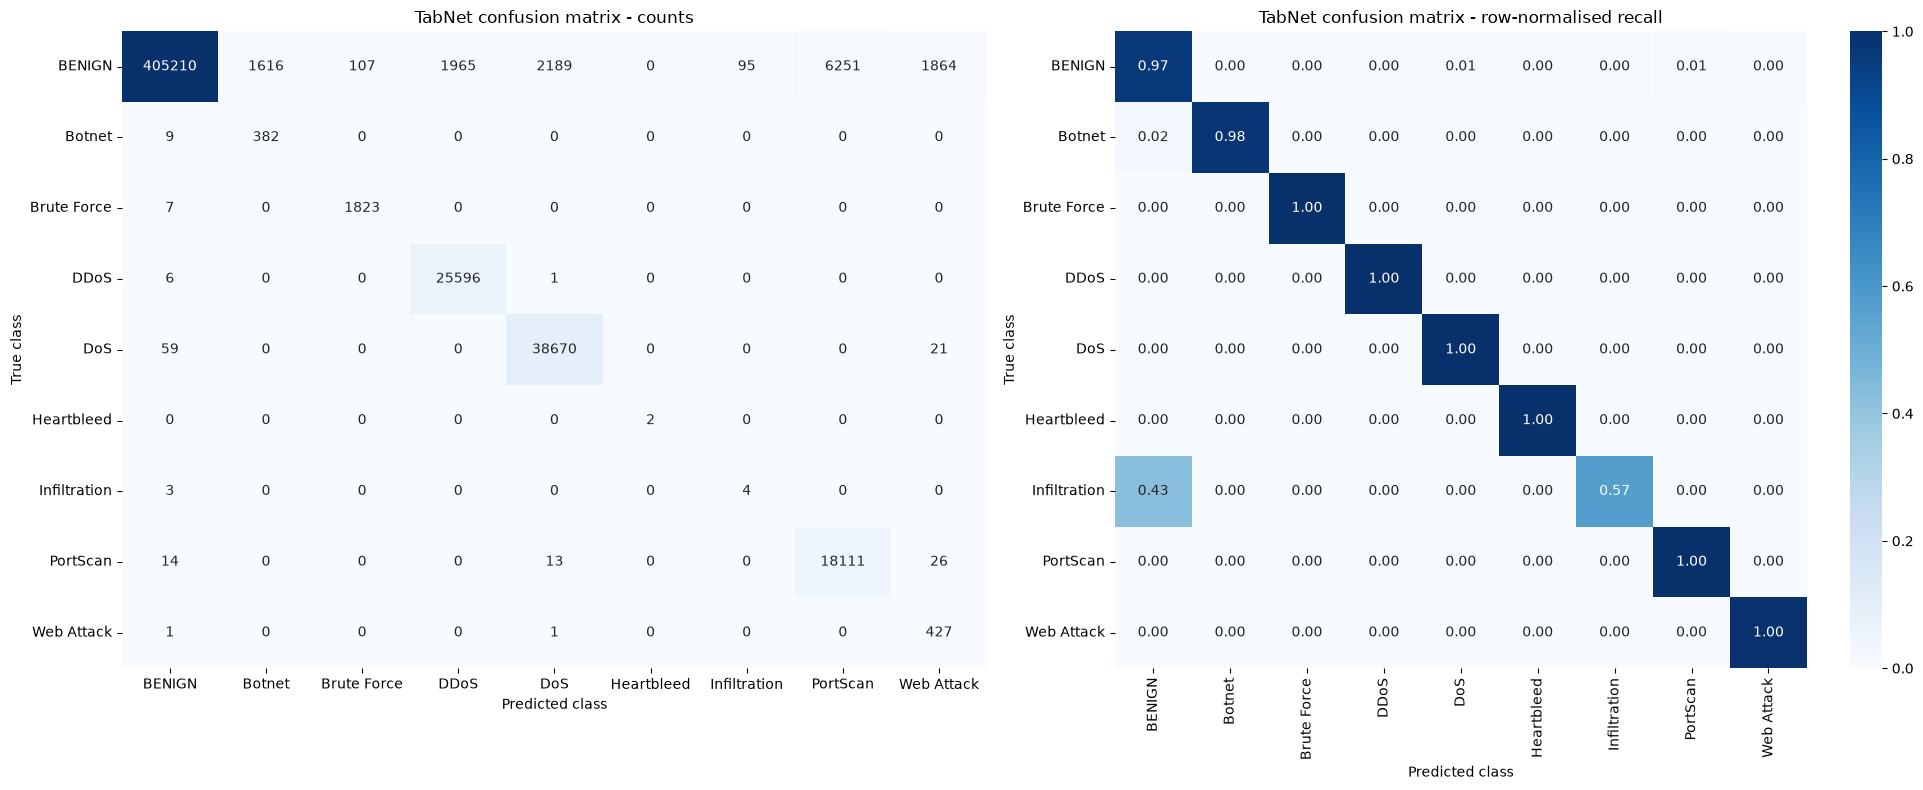

In [14]:
confusion = confusion_matrix(y_test, test_predictions, labels=all_labels)
row_normalised = confusion / np.maximum(confusion.sum(axis=1, keepdims=True), 1)
figure, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(confusion, cmap='Blues', annot=True, fmt='d', cbar=False, xticklabels=class_names, yticklabels=class_names, ax=axes[0])
sns.heatmap(row_normalised, cmap='Blues', annot=True, fmt='.2f', vmin=0, vmax=1, xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[0].set_title('TabNet confusion matrix - counts')
axes[1].set_title('TabNet confusion matrix - row-normalised recall')
for axis in axes:
    axis.set_xlabel('Predicted class')
    axis.set_ylabel('True class')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

### Save binary metrics, predictions, model size and final summary

In [15]:
y_test_binary = (y_test != BENIGN_INDEX).astype(int)
test_predictions_binary = (test_predictions != BENIGN_INDEX).astype(int)
attack_score = 1.0 - test_probabilities[:, BENIGN_INDEX]
tn, fp, fn, tp = confusion_matrix(y_test_binary, test_predictions_binary, labels=[0, 1]).ravel()
binary_precision, binary_recall, binary_f1, _ = precision_recall_fscore_support(
    y_test_binary, test_predictions_binary, average='binary', zero_division=0,
)
binary_metrics = {
    'precision': binary_precision,
    'recall_detection_rate': binary_recall,
    'f1': binary_f1,
    'roc_auc': roc_auc_score(y_test_binary, attack_score),
    'pr_auc': average_precision_score(y_test_binary, attack_score),
    'false_positive_rate': fp / max(fp + tn, 1),
    'mcc': matthews_corrcoef(y_test_binary, test_predictions_binary),
    'true_negative': int(tn),
    'false_positive': int(fp),
    'false_negative': int(fn),
    'true_positive': int(tp),
}
display(pd.Series(binary_metrics).round(4))

precision                     0.8579
recall_detection_rate         0.9988
f1                            0.9230
roc_auc                       0.9978
pr_auc                        0.9897
false_positive_rate           0.0336
mcc                           0.9099
true_negative            405210.0000
false_positive            14087.0000
false_negative               99.0000
true_positive             85077.0000
dtype: float64

### Save reusable metrics, predictions and model statistics

In [16]:
trainable_parameters = sum(parameter.numel() for parameter in tabnet_model.network.parameters() if parameter.requires_grad)
efficiency = {
    'trainable_parameters': int(trainable_parameters),
    'model_file_mb': MODEL_FILE.stat().st_size / 1024 ** 2,
    'training_seconds': training_seconds,
    'inference_seconds': inference_seconds,
    'inference_ms_per_1000_rows': 1000 * 1000 * inference_seconds / len(X_test),
    'explainability_seconds': explain_seconds,
    'epochs_run': len(history),
    'best_validation_macro_f1': best_validation_macro_f1,
    'device': device_name,
}
metrics = {
    'model': 'TabNet',
    'selection_metric': 'validation_macro_f1',
    'class_weighting': 'pytorch_tabnet balanced training sample weights (weights=1)',
    'config': FINAL_CONFIG,
    'multiclass': {key: float(value) for key, value in multiclass_metrics.items()},
    'binary_benign_vs_attack': {
        key: (float(value) if isinstance(value, (float, np.floating)) else value)
        for key, value in binary_metrics.items()
    },
    'efficiency': efficiency,
}
with open(RESULTS_DIR / 'metrics.json', 'w') as file:
    json.dump(metrics, file, indent=2)
np.savez_compressed(
    RESULTS_DIR / 'test_predictions.npz',
    y_true=y_test,
    y_pred=test_predictions,
    probabilities=test_probabilities.astype(np.float32),
    class_names=np.array(class_names),
)
pd.DataFrame({'y_true': y_test, 'y_pred': test_predictions}).to_csv(
    RESULTS_DIR / 'test_predictions.csv', index=False,
)
summary = pd.concat([
    pd.Series(multiclass_metrics).add_prefix('multiclass_'),
    pd.Series(binary_metrics).add_prefix('binary_'),
    pd.Series(efficiency),
])
summary.to_csv(RESULTS_DIR / 'summary.csv', header=['value'])
print('Saved TabNet model, metrics, predictions and figures in', RESULTS_DIR)

Saved TabNet model, metrics, predictions and figures in d:\Projects\SE4050-DL\results\tabnet
